# Tutorial Inicial: Conexión, Control y Visualización en RoboCup 2D

**Curso:** DS5345 · Aprendizaje por Refuerzo (UTEC 2026-2)  
**Objetivo:** Verificar la comunicación con el servidor `rcssserver` en Docker, ejecutar un ciclo de percepción-acción y visualizar el terreno de juego 2D.


In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import time
import random
import numpy as np
import matplotlib.pyplot as plt
import sys

sys.path.append("/workspace/src")
from robocup_client import RoboCup2DClient

SERVER_HOST = os.getenv("SERVER_HOST", "rcssserver")
SERVER_PORT = int(os.getenv("SERVER_PORT", "6000"))
print(f"Configuración del servidor: {SERVER_HOST}:{SERVER_PORT}")

Configuración del servidor: rcssserver:6000


## 1. Conexión e Inicialización del Jugador en el Campo

El cliente realiza el handshake UDP `(init UTEC_RL ...)` y ubica automáticamente al jugador en la posición `(-10.0, 0.0)` mediante `(move -10 0)`.


In [3]:
client = RoboCup2DClient(host=SERVER_HOST, port=SERVER_PORT, team_name="UTEC_RL")
success = client.connect(init_pos=(-10.0, 0.0))

if success:
    print(
        f"¡Handshake completado! Lado: {client.side} | Dorsal: {client.uniform_number} | Modo: {client.play_mode}"
    )
else:
    print(
        "Error de conexión con el simulador. Verifica que el contenedor robocup_server esté corriendo."
    )

Conectado a RoboCup 2D | Equipo: UTEC_RL | Lado: l | Dorsal: 1 | Modo: play_on
¡Handshake completado! Lado: l | Dorsal: 1 | Modo: play_on


## 2. Bucle de Percepción y Acción (Baseline Aleatorio/Heurístico)

El jugador recibe información relativa en mensajes `(see ...)` y decide entre:

- `DASH(power)`: Acelerar hacia adelante.
- `TURN(moment)`: Girar el cuerpo hacia el balón.
- `KICK(power, dir)`: Patear el balón hacia la portería rival si está cerca ($d < 0.8\text{m}$).


In [4]:
print("Iniciando ciclo de control durante 50 pasos...")
print("-" * 70)
distances_to_ball = []

try:
    for step in range(50):
        obs = client.get_latest_observation()
        ball = obs["ball"]
        goal = obs["goal_opp"]

        if ball is not None:
            dist, angle = ball
            distances_to_ball.append(dist)
            if dist < 0.8:
                kick_dir = goal[1] if goal is not None else random.uniform(-30, 30)
                client.kick(power=100.0, direction=kick_dir)
                action_desc = f"KICK(power=100, dir={kick_dir:.1f}°)"
            elif abs(angle) > 10:
                client.turn(moment=angle)
                action_desc = f"TURN(dir={angle:.1f}°)"
            else:
                client.dash(power=80.0)
                action_desc = f"DASH(power=80)"
        else:
            client.turn(moment=45.0)
            action_desc = "SEARCH_BALL (TURN 45°)"

        ball_str = (
            f"Dist: {ball[0]:.1f}m, Dir: {ball[1]:.1f}°"
            if ball
            else "Buscando balón..."
        )
        print(f"Paso {step:02d} | Balón: {ball_str:<25} | Acción: {action_desc}")
        time.sleep(0.08)

except KeyboardInterrupt:
    print("\nDeteniendo bucle...")

Iniciando ciclo de control durante 50 pasos...
----------------------------------------------------------------------
Paso 00 | Balón: Buscando balón...         | Acción: SEARCH_BALL (TURN 45°)
Paso 01 | Balón: Buscando balón...         | Acción: SEARCH_BALL (TURN 45°)
Paso 02 | Balón: Buscando balón...         | Acción: SEARCH_BALL (TURN 45°)
Paso 03 | Balón: Dist: 36.6m, Dir: -8.0°   | Acción: DASH(power=80)
Paso 04 | Balón: Dist: 36.6m, Dir: -8.0°   | Acción: DASH(power=80)
Paso 05 | Balón: Buscando balón...         | Acción: SEARCH_BALL (TURN 45°)
Paso 06 | Balón: Buscando balón...         | Acción: SEARCH_BALL (TURN 45°)
Paso 07 | Balón: Buscando balón...         | Acción: SEARCH_BALL (TURN 45°)
Paso 08 | Balón: Buscando balón...         | Acción: SEARCH_BALL (TURN 45°)
Paso 09 | Balón: Buscando balón...         | Acción: SEARCH_BALL (TURN 45°)
Paso 10 | Balón: Buscando balón...         | Acción: SEARCH_BALL (TURN 45°)
Paso 11 | Balón: Buscando balón...         | Acción: SEARCH_BA

## 3. Visualización del Terreno de Juego 2D (Pitch Render)

Renderizamos la posición del campo oficial (105m x 68m) con la ubicación del jugador y el balón.


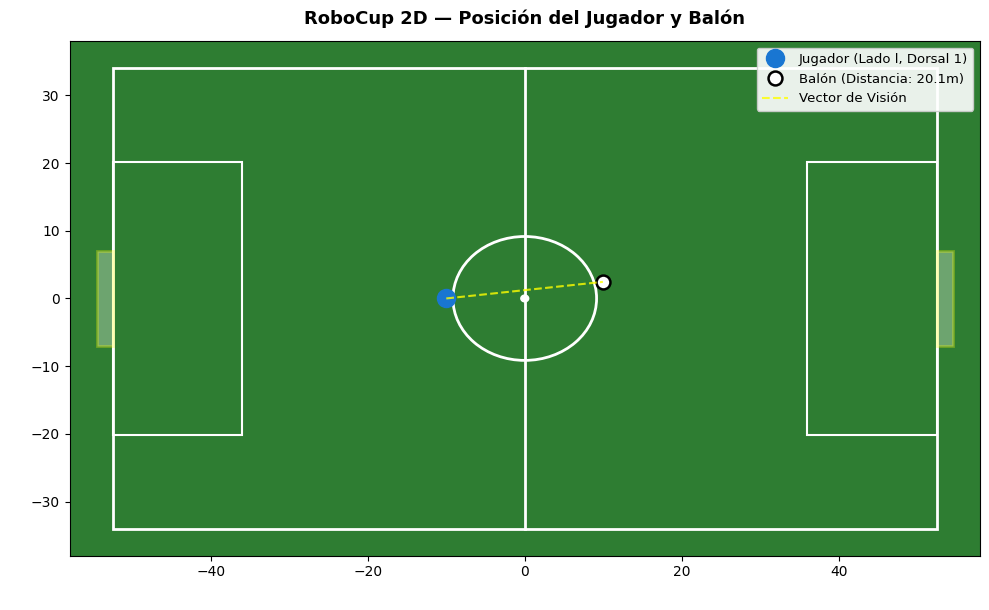

Agente desconectado correctamente.


In [9]:
# Renderizar el campo de juego y cerrar conexión
client.render_field(title="RoboCup 2D — Posición del Jugador y Balón")
client.close()
print("Agente desconectado correctamente.")